In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
np.random.seed(42)
Values=np.random.randn(365)
Values

array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337,
       -0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004,
       -0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783,
       -0.56228753, -1.01283112,  0.31424733, -0.90802408, -1.4123037 ,
        1.46564877, -0.2257763 ,  0.0675282 , -1.42474819, -0.54438272,
        0.11092259, -1.15099358,  0.37569802, -0.60063869, -0.29169375,
       -0.60170661,  1.85227818, -0.01349722, -1.05771093,  0.82254491,
       -1.22084365,  0.2088636 , -1.95967012, -1.32818605,  0.19686124,
        0.73846658,  0.17136828, -0.11564828, -0.3011037 , -1.47852199,
       -0.71984421, -0.46063877,  1.05712223,  0.34361829, -1.76304016,
        0.32408397, -0.38508228, -0.676922  ,  0.61167629,  1.03099952,
        0.93128012, -0.83921752, -0.30921238,  0.33126343,  0.97554513,
       -0.47917424, -0.18565898, -1.10633497, -1.19620662,  0.81252582,
        1.35624003, -0.07201012,  1.0035329 ,  0.36163603, -0.64

In [34]:
Dates=pd.date_range(start='2025-01-01', end='2025-12-31',freq='D')
Dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

In [35]:
df=pd.DataFrame(Values, index=Dates, columns=['Value'])
df

,Value
2025-01-01,0.496714
2025-01-02,-0.138264
2025-01-03,0.647689
2025-01-04,1.523030
2025-01-05,-0.234153
...,...
2025-12-27,0.519347
2025-12-28,1.532739
2025-12-29,-0.108760
2025-12-30,0.401712


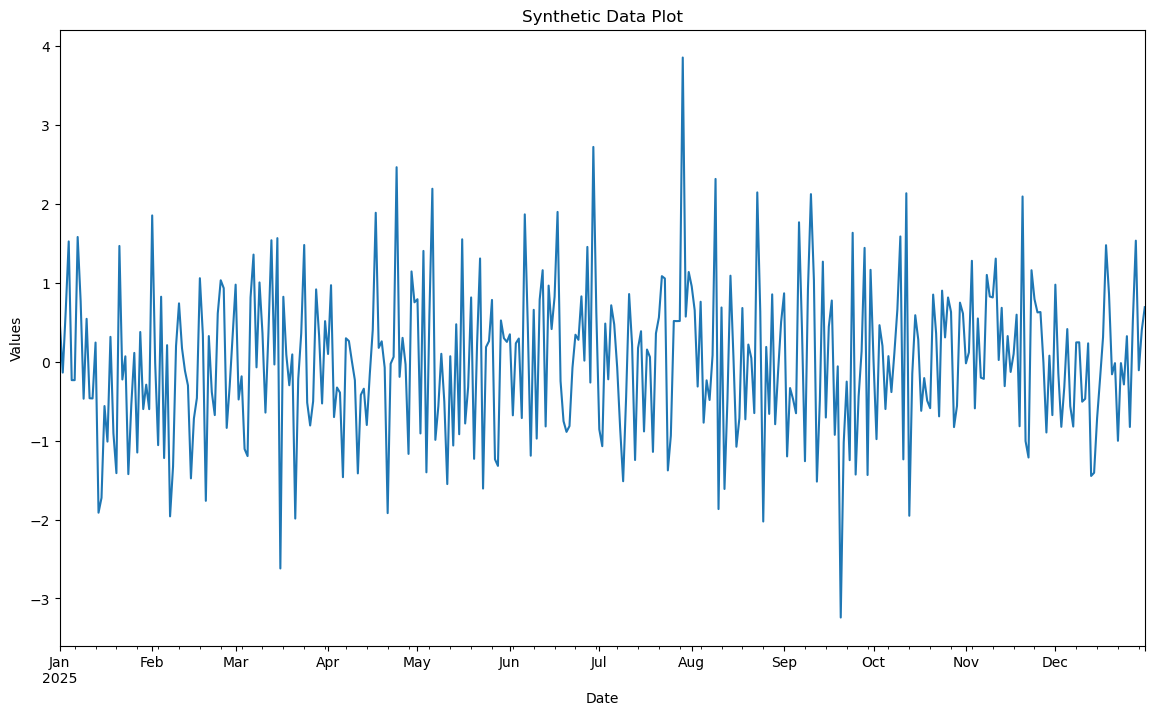

In [36]:
df.plot(title= "Synthetic Data Plot", figsize=(14,8), legend=None)
plt.xlabel("Date")
plt.ylabel("Values")
plt.show()

<h1>Automatic Differencing</h1>

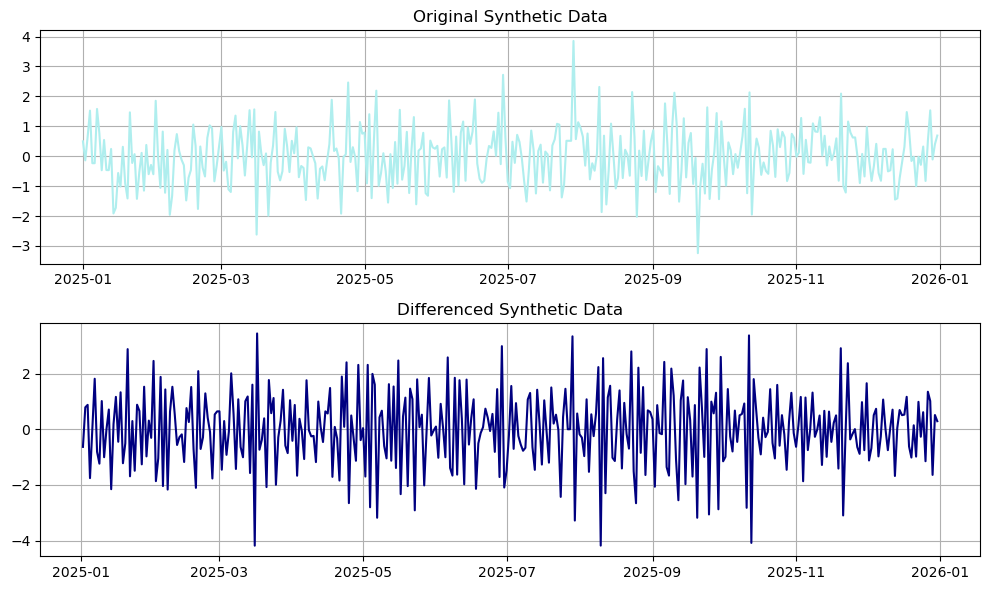

In [37]:
series=df
differenced_series=series.diff(periods=1)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(series, label='Original Series', color='paleturquoise')
plt.title('Original Synthetic Data')
plt.grid()

plt.subplot(2,1,2)
plt.plot(differenced_series, label='Differenced Series', color='navy')
plt.title("Differenced Synthetic Data")
plt.grid()

plt.tight_layout()
plt.show()

<h1>Manual Differencing</h1>

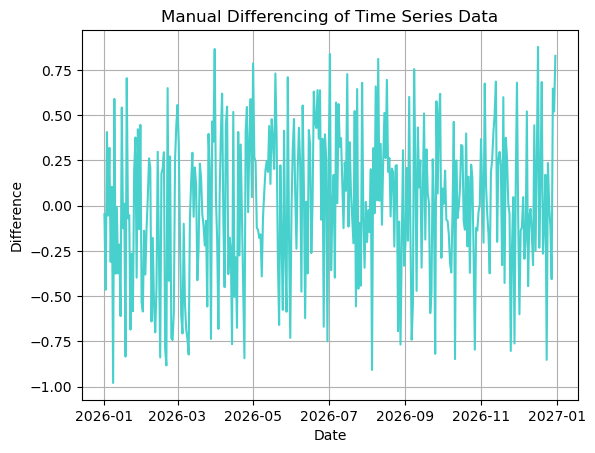

In [38]:
dates = pd.date_range(start='2025-01-01', periods=730, freq='D') 
values = np.random.rand(730)  

data = pd.DataFrame(values, index=dates, columns=['Value'])

X = data.values
diff = list()
days_in_year = 365
for i in range(days_in_year, len(X)):
    value = X[i] - X[i - days_in_year]
    diff.append(value)

# Plot the differenced data
plt.plot(data.index[days_in_year:], diff, color='mediumturquoise')  
plt.title('Manual Differencing of Time Series Data')
plt.xlabel('Date')
plt.ylabel('Difference')
plt.grid(True) 

In [39]:
df_values=pd.DataFrame(Values, index=Dates, columns=['Value'])
print(df_values.head())

               Value
2025-01-01  0.496714
2025-01-02 -0.138264
2025-01-03  0.647689
2025-01-04  1.523030
2025-01-05 -0.234153


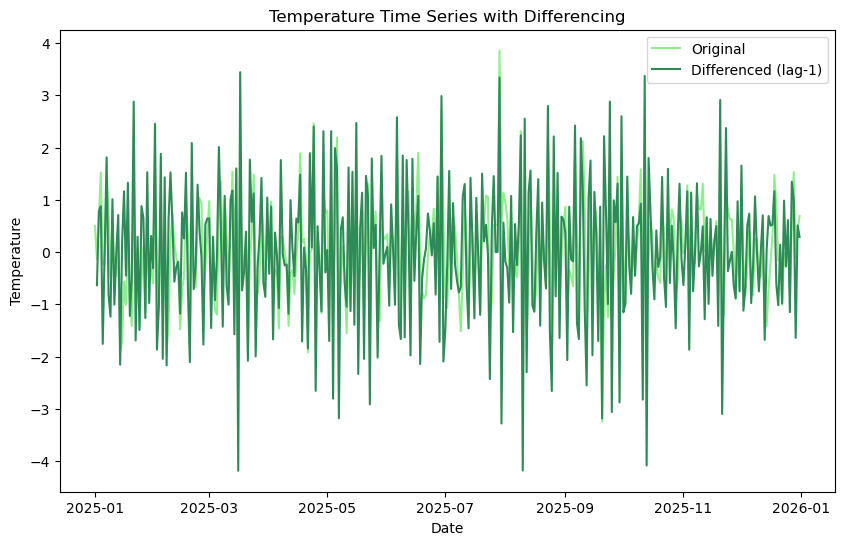

In [40]:
df_values['diff']=df_values['Value'].diff(periods=1)

plt.figure(figsize=(10,6))
plt.plot(df_values.index, df_values['Value'], label="Original", color='lightgreen')
plt.plot(df_values.index, df_values['diff'], label="Differenced (lag-1)", color='seagreen')
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.title("Temperature Time Series with Differencing")
plt.legend()
plt.show()

<h1>Fitting Polynomials</h1>

Coefficients: [[ 4.15865576e-10]
 [-3.00513997e-07]
 [ 6.51406840e-05]
 [-3.35753708e-03]
 [-9.27400349e-02]]


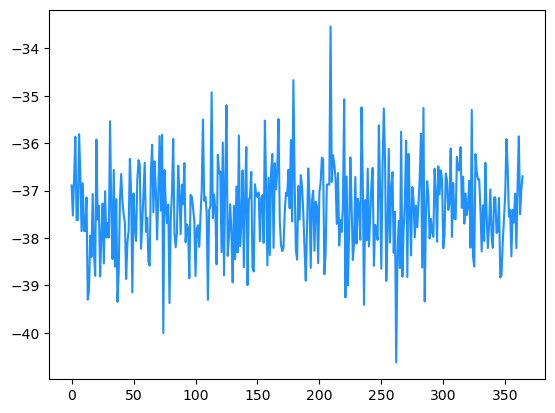

In [42]:
from numpy import polyfit

series=pd.DataFrame(Values, index=Dates, columns=['Value'])
X=series.values
X=[i%365 for i in range(0, len(series))]
y=series.values
degree=4
coef=polyfit(X,y,degree)
print("Coefficients: %s" % coef)

curve=list()
for i in range(len(X)):
    value=coef[-1]
    for d in range(degree):
        value += X[i]**(degree-d) * coef[d]
        curve.append(value)

values=series.values
diff=list()
for i in range(len(values)):
    value=values[i] - curve[i]
    diff.append(value)
plt.plot(diff, color='dodgerblue')
plt.show()